#### Importing Necessary Libraries

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import unix_timestamp
from pyspark.sql.functions import lit
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import hour, dayofweek, month, year
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.sql.functions import monotonically_increasing_id, col

## Part 1: Data Ingestion and Preparation

#### 1.1 Mount the Azure Blob Storage into the Databricks File System

Add STORAGE ACCOUNT NAME into a variable called storage_account_name

In [ ]:
storage_account_name = "#notsharedname"

 Add STORAGE ACCOUNT ACCESS KEY into a variable called storage_account_access_key

In [ ]:
storage_account_access_key = "#notsharedkey"

Add the container name into a variable called blob_container_name

In [ ]:
blob_container_name = "bde-assignment2"

Mount the blob container into the Databricks Files System

In [ ]:
try:
    dbutils.fs.mount(
        source = f'wasbs://{blob_container_name}@{storage_account_name}.blob.core.windows.net',
        mount_point = f'/mnt/{blob_container_name}/',
        extra_configs = {'fs.azure.account.key.' + storage_account_name + '.blob.core.windows.net': storage_account_access_key}
    )
    print(f"Successfully mounted {blob_container_name}")
except Exception as e:
    if "Directory already mounted" in str(e):
        print("Directory has been already mounted")
    else:
        print(f"An error occurred: {str(e)}")

Directory has been already mounted


List the files inside your moutned Azure container:

In [ ]:
dbutils.fs.ls("/mnt/bde-assignment2/")

Out[6]: [FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2015.parquet', name='green_taxi_2015.parquet', size=404556105, modificationTime=1727086466000),
 FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2015_csv/', name='green_taxi_2015_csv/', size=0, modificationTime=1727272170000),
 FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2016.parquet', name='green_taxi_2016.parquet', size=346731598, modificationTime=1727086369000),
 FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2017.parquet', name='green_taxi_2017.parquet', size=251504885, modificationTime=1727086208000),
 FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2018.parquet', name='green_taxi_2018.parquet', size=193874396, modificationTime=1727086098000),
 FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2019.parquet', name='green_taxi_2019.parquet', size=142163406, modificationTime=1727086027000),
 FileInfo(path='dbfs:/mnt/bde-assignment2/green_taxi_2020.parquet', name='green_taxi_2020.parquet', size=3707674

#### 1.2 Make a copy of the datasets into DBFS

##### Copy Green Taxi Files into DBFS

In [ ]:
green_taxi_files = [
    "green_taxi_2015.parquet", "green_taxi_2016.parquet", "green_taxi_2017.parquet",
    "green_taxi_2018.parquet", "green_taxi_2019.parquet", "green_taxi_2020.parquet",
    "green_taxi_2021.parquet", "green_taxi_2022.parquet"
]

for file in green_taxi_files:
    source_path = f"/mnt/bde-assignment2/{file}"
    destination_path = f"/dbfs/taxi_data/green_taxi/{file}"
    dbutils.fs.cp(source_path, destination_path)


##### Copy Yellow Taxi Files into DBFS

In [ ]:
yellow_taxi_files = [
    "yellow_taxi_2015.parquet", "yellow_taxi_2016.parquet", "yellow_taxi_2017.parquet",
    "yellow_taxi_2018.parquet", "yellow_taxi_2019.parquet", "yellow_taxi_2020.parquet",
    "yellow_taxi_2021.parquet", "yellow_taxi_2022.parquet"
]

for file in yellow_taxi_files:
    source_path = f"/mnt/bde-assignment2/{file}"
    destination_path = f"/dbfs/taxi_data/yellow_taxi/{file}"
    dbutils.fs.cp(source_path, destination_path)

##### Load the parquet files

Loading Green Taxi Data

In [ ]:
green_taxi_df = spark.read.parquet("/dbfs/taxi_data/green_taxi/*.parquet")
green_taxi_df.createOrReplaceTempView("green_taxi")

Loading Yellow Taxi Data

In [ ]:
yellow_taxi_df = spark.read.parquet("/dbfs/taxi_data/yellow_taxi/*.parquet")
yellow_taxi_df.createOrReplaceTempView("yellow_taxi")

#### 1.3 Counting the Rows Using Spark SQL

##### Counting Rows for Green Taxi Data

In [ ]:
%sql
SELECT COUNT(*) AS total_green_taxi_rows FROM green_taxi;


total_green_taxi_rows
66200401


##### Counting Rows for Yellow Taxi Data

In [ ]:
%sql
SELECT COUNT(*) AS total_yellow_taxi_rows FROM yellow_taxi;

total_yellow_taxi_rows
663055251


#### 1.4 Generating the directory for loading the Location Referential CSV

In [ ]:
dbutils.fs.mkdirs("/FileStore/assignment2")

Out[10]: True

Load the CSV file into a Spark DataFrame

In [ ]:
taxi_zone_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/FileStore/assignment2/taxi_zone_lookup.csv")

taxi_zone_df.createOrReplaceTempView("taxi_zone_lookup")

In [ ]:
taxi_zone_df.show(10)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
|         6|Staten Island|Arrochar/Fort Wad...|   Boro Zone|
|         7|       Queens|             Astoria|   Boro Zone|
|         8|       Queens|        Astoria Park|   Boro Zone|
|         9|       Queens|          Auburndale|   Boro Zone|
|        10|       Queens|        Baisley Park|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 10 rows



#### 1.5 Working with the “Green” 2015 parquet file

##### Read the Green Taxi 2015 Parquet File

In [ ]:
green_taxi_2015_df = spark.read.parquet("/dbfs/taxi_data/green_taxi/green_taxi_2015.parquet")

##### Convert the DataFrame to CSV

In [ ]:
green_taxi_2015_df.coalesce(1).write.mode("overwrite").option("header", "true").csv("/dbfs/taxi_data/green_taxi_2015_csv")

##### Upload the “Green” 2015 CSV File to Azure Blob Storage

In [ ]:
dbutils.fs.cp("/dbfs/taxi_data/green_taxi_2015_csv", "/mnt/bde-assignment2/green_taxi_2015_csv/", True)

Out[16]: True

##### Compare File Sizes

###### Size of the Parquet file

In [ ]:
parquet_size = dbutils.fs.ls("/dbfs/taxi_data/green_taxi/green_taxi_2015.parquet")
total_parquet_size = sum(file.size for file in parquet_size)
print(f"Size of the Green Taxi 2015 Parquet file: {total_parquet_size / (1024 * 1024)} MB")

Size of the Green Taxi 2015 Parquet file: 385.8147668838501 MB


###### Size of the CSV file

In [ ]:
csv_size = dbutils.fs.ls("/dbfs/taxi_data/green_taxi_2015_csv")
total_csv_size = sum(file.size for file in csv_size)
print(f"Size of the Green Taxi 2015 CSV file: {total_csv_size / (1024 * 1024)} MB")


Size of the Green Taxi 2015 CSV file: 2078.168189048767 MB


In [ ]:
# Read the Parquet file into a DataFrame
green_taxi_2015_df = spark.read.parquet("/dbfs/taxi_data/green_taxi/green_taxi_2015.parquet")

# Print the schema to see column names and data types
green_taxi_2015_df.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- lpep_pickup_datetime: timestamp (nullable = true)
 |-- lpep_dropoff_datetime: timestamp (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- trip_type: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)



#### 1.6 Dataset Exploration and Data Cleaning

Load the Green and Yellow Taxi Data

In [ ]:
green_taxi_df = spark.sql("SELECT * FROM green_taxi")
yellow_taxi_df = spark.sql("SELECT * FROM yellow_taxi")

##### Visualizing Schema

In [ ]:
# For Green Taxi
green_taxi_df.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- lpep_pickup_datetime: timestamp (nullable = true)
 |-- lpep_dropoff_datetime: timestamp (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- trip_type: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)



In [ ]:
# For Yellow Taxi
yellow_taxi_df.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



In [ ]:
green_taxi_df.createOrReplaceTempView("green_taxi_table")
yellow_taxi_df.createOrReplaceTempView("yellow_taxi_table")

#### Visualizing the dataset for Green taxis

In [ ]:
%sql
SELECT * FROM green_taxi_table LIMIT 10;

VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
2,2015-05-01T00:24:18.000+0000,2015-05-01T00:24:39.000+0000,N,1.0,146,146,1.0,0.0,2.5,0.5,0.5,0.0,0.0,null,0.3,3.8,2.0,1.0,null
2,2015-05-01T00:28:15.000+0000,2015-05-01T00:29:00.000+0000,N,1.0,146,146,1.0,0.0,2.5,0.5,0.5,0.0,0.0,null,0.3,3.8,2.0,1.0,null
2,2015-05-01T00:07:45.000+0000,2015-05-01T00:12:50.000+0000,N,1.0,255,112,1.0,1.09,5.5,0.5,0.5,1.0,0.0,null,0.3,7.8,1.0,1.0,null
2,2015-05-01T00:26:23.000+0000,2015-05-01T00:55:12.000+0000,N,1.0,255,13,1.0,5.73,22.0,0.5,0.5,4.66,0.0,null,0.3,27.96,1.0,1.0,null
2,2015-05-01T00:20:16.000+0000,2015-05-01T00:30:37.000+0000,N,1.0,80,225,1.0,2.35,9.5,0.5,0.5,0.0,0.0,null,0.3,10.8,2.0,1.0,null
2,2015-05-01T00:37:21.000+0000,2015-05-01T00:50:00.000+0000,N,1.0,37,112,1.0,2.68,11.0,0.5,0.5,3.08,0.0,null,0.3,15.38,1.0,1.0,null
2,2015-05-01T00:06:15.000+0000,2015-05-01T00:31:20.000+0000,N,1.0,255,164,1.0,4.74,19.5,0.5,0.5,0.0,0.0,null,0.3,20.8,2.0,1.0,null
2,2015-05-01T00:22:31.000+0000,2015-05-01T01:05:05.000+0000,N,1.0,17,68,1.0,6.47,29.5,0.5,0.5,0.0,0.0,null,0.3,30.8,2.0,1.0,null
2,2015-05-01T00:27:04.000+0000,2015-05-01T00:35:33.000+0000,N,1.0,112,226,5.0,2.25,9.0,0.5,0.5,2.06,0.0,null,0.3,12.36,1.0,1.0,null
2,2015-05-01T00:19:16.000+0000,2015-05-01T00:35:52.000+0000,N,1.0,255,52,1.0,4.9,17.5,0.5,0.5,3.76,0.0,null,0.3,22.56,1.0,1.0,null


#### Visualizing the dataset for Yellow taxis

In [ ]:
%sql
SELECT * FROM yellow_taxi_table LIMIT 10;

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
1,2015-01-01T00:11:33.000+0000,2015-01-01T00:16:48.000+0000,1.0,1.0,1.0,N,41,166,1,5.7,0.5,0.5,1.4,0.0,0.0,8.4,null,null
1,2015-01-01T00:18:24.000+0000,2015-01-01T00:24:20.000+0000,1.0,0.9,1.0,N,166,238,3,6.0,0.5,0.5,0.0,0.0,0.0,7.3,null,null
1,2015-01-01T00:26:19.000+0000,2015-01-01T00:41:06.000+0000,1.0,3.5,1.0,N,238,162,1,13.2,0.5,0.5,2.9,0.0,0.0,17.4,null,null
1,2015-01-01T00:45:26.000+0000,2015-01-01T00:53:20.000+0000,1.0,2.1,1.0,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,null,null
1,2015-01-01T00:59:21.000+0000,2015-01-01T01:05:24.000+0000,1.0,1.0,1.0,N,236,141,3,6.0,0.5,0.5,0.0,0.0,0.0,7.3,null,null
1,2015-01-01T00:07:31.000+0000,2015-01-01T00:11:32.000+0000,1.0,0.8,1.0,N,239,238,2,5.0,0.5,0.5,0.0,0.0,0.0,6.3,null,null
1,2015-01-01T00:47:08.000+0000,2015-01-01T00:54:50.000+0000,1.0,1.1,1.0,N,238,239,2,7.0,0.5,0.5,0.0,0.0,0.0,8.3,null,null
1,2015-01-01T00:58:04.000+0000,2015-01-01T01:11:56.000+0000,1.0,2.9,1.0,N,238,42,1,12.2,0.5,0.5,2.7,0.0,0.0,16.2,null,null
1,2015-01-01T00:29:25.000+0000,2015-01-01T00:37:25.000+0000,2.0,1.3,1.0,N,90,125,2,7.0,0.5,0.5,0.0,0.0,0.0,8.3,null,null
1,2015-01-01T00:39:02.000+0000,2015-01-01T01:02:37.000+0000,2.0,4.3,1.0,N,125,141,2,18.0,0.5,0.5,0.0,0.0,0.0,19.3,null,null


##### Analysing Top Pick up locations for Green and Yellow taxis

In [ ]:
def pickup_location(df):
    df=df.groupBy("PULocationID").agg({"PULocationID": "count"})
    df=df.sort(col('count(PULocationID)').desc())
    df=df.select(col('PULocationID'), col('count(PULocationID)').alias('count')).limit(5)
    return df

In [ ]:
# For green taxi
pickup_location(green_taxi_df).show()

+------------+-------+
|PULocationID|  count|
+------------+-------+
|          74|3940683|
|          41|3512123|
|          75|3415470|
|           7|3008143|
|          82|2658298|
+------------+-------+



In [ ]:
# For yellow taxi
pickup_location(yellow_taxi_df).show()

+------------+--------+
|PULocationID|   count|
+------------+--------+
|         237|26803919|
|         161|24663410|
|         236|24342496|
|         186|22481441|
|         162|22365759|
+------------+--------+



##### Analysing Top Drop off locations for Green and Yellow taxis

In [ ]:
def dropoff_location(df):
    df=df.groupBy("DOLocationID").agg({"DOLocationID": "count"})
    df=df.sort(col('count(DOLocationID)').desc())
    df=df.select(col('DOLocationID'), col('count(DOLocationID)').alias('count')).limit(5)
    return df

In [ ]:
# For green taxi
dropoff_location(green_taxi_df).show()

+------------+-------+
|DOLocationID|  count|
+------------+-------+
|          74|2141866|
|          42|2113383|
|          41|1870492|
|           7|1859264|
|         129|1720407|
+------------+-------+



In [ ]:
# For yellow taxi
dropoff_location(yellow_taxi_df).show()

+------------+--------+
|DOLocationID|   count|
+------------+--------+
|         236|24795550|
|         161|24578969|
|         237|23443565|
|         170|20825824|
|         230|19925306|
+------------+--------+



##### Analysing total_amount for Green and Yellow taxis

In [ ]:
# For Green taxi
green_taxi_df.select("total_amount").describe().toPandas()

,summary,total_amount
0,count,66200401
1,mean,15.528623431472889
2,stddev,122.37304907093659
3,min,-890.3
4,max,989970.39


In [ ]:
# For Yellow taxi
yellow_taxi_df.select("total_amount").describe().toPandas()

,summary,total_amount
0,count,663055251
1,mean,17.227453900471343
2,stddev,232.4413282762861
3,min,-2567.8
4,max,3950611.6


In both green and yellow taxi datasets, there are negative amounts which are unreasonable.

##### Visualizing any odd dates for the trips of green taxis

... completed job in 22.48643732070923 seconds


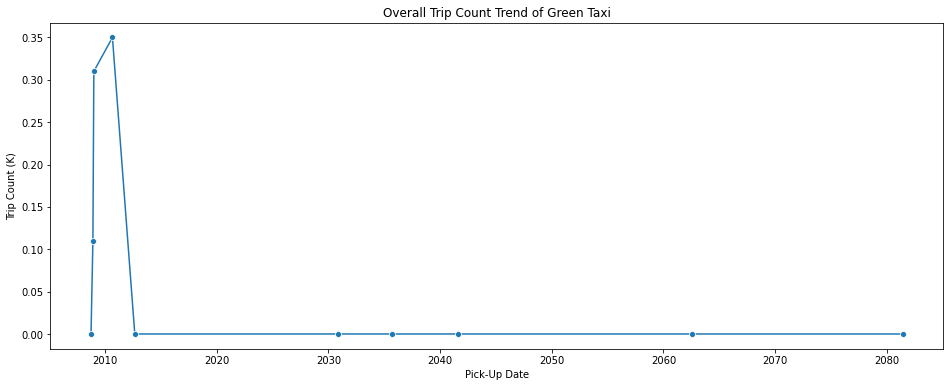

In [ ]:
query = """
SELECT
    DATE_TRUNC('MM', c.lpep_pickup_datetime) AS date_month,
    ROUND(COUNT(1)/1000, 2) AS trip_count_k
FROM
    green_taxi_table c
WHERE
    c.lpep_pickup_datetime IS NOT NULL 
    AND (YEAR(c.lpep_pickup_datetime) < 2015 OR YEAR(c.lpep_pickup_datetime) > 2022)
GROUP BY
    date_month
ORDER BY 
    date_month
"""

start = time.time()
pd_df = spark.sql(query).toPandas()
print(f"... completed job in {time.time() - start} seconds")

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x='date_month', y='trip_count_k', data=pd_df, ax=ax, marker='o')

ax.set_title("Overall Trip Count Trend of Green Taxi")
ax.set_ylabel("Trip Count (K)")
ax.set_xlabel("Pick-Up Date")

plt.show()

##### Visualizing any odd dates for the trips of yellow taxis

... completed job in 186.651709318161 seconds


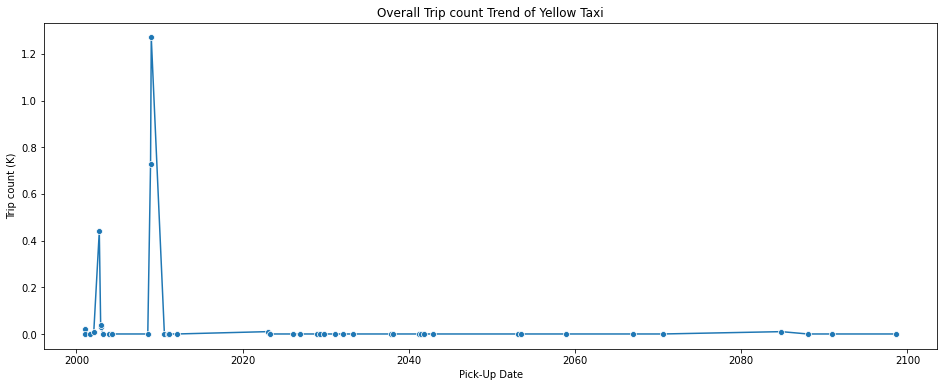

In [ ]:
query = """
SELECT
    DATE_TRUNC('MM', y.tpep_pickup_datetime) AS date_month,
    ROUND(COUNT(1)/1000, 2) AS trip_count_k
FROM
    yellow_taxi_table y
WHERE
    y.tpep_pickup_datetime IS NOT NULL 
    AND (YEAR(y.tpep_pickup_datetime) < 2015 OR YEAR(y.tpep_pickup_datetime) > 2022)
GROUP BY
    date_month
ORDER BY 
    date_month
"""

start = time.time()
pd_df = spark.sql(query).toPandas()
print(f"... completed job in {time.time() - start} seconds")

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(x='date_month', y='trip_count_k', data=pd_df, ax=ax, marker='o')

ax.set_title("Overall Trip count Trend of Yellow Taxi")
ax.set_ylabel("Trip count (K)")
ax.set_xlabel("Pick-Up Date")

plt.show()

In both yellow and green taxi datasets, there are timelines where the dates are way in the past of the year 2015 and way ahead in the future of the year 2022, which are unusual. 

##### Visualizing fare amounts for the trips of green taxis

... completed job in 54.67737936973572 seconds


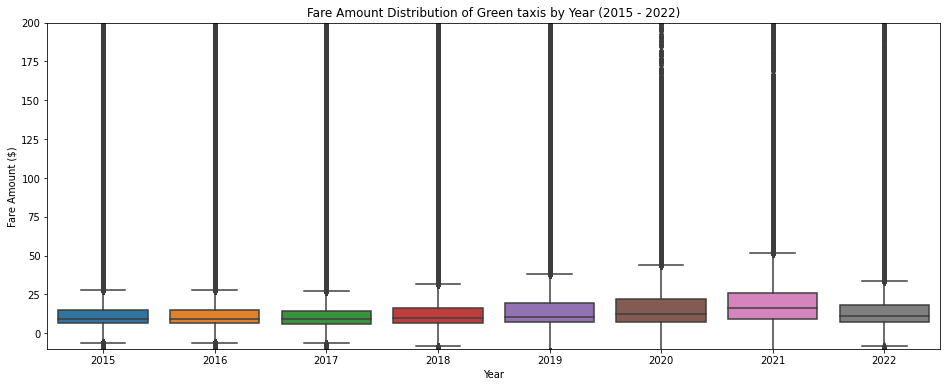

In [ ]:
query = """
SELECT
    YEAR(lpep_pickup_datetime) AS year,
    fare_amount
FROM
    green_taxi_table
WHERE 
    lpep_pickup_datetime IS NOT NULL 
    AND fare_amount IS NOT NULL 
    AND YEAR(lpep_pickup_datetime) BETWEEN 2015 AND 2022
"""

start = time.time()
fare_df = spark.sql(query).toPandas()
print(f"... completed job in {time.time() - start} seconds")


plt.figure(figsize=(16, 6))
sns.boxplot(x='year', y='fare_amount', data=fare_df)

plt.title("Fare Amount Distribution of Green taxis by Year (2015 - 2022)")
plt.ylabel("Fare Amount ($)")
plt.xlabel("Year")
plt.ylim(-10, 200) 
plt.show()

##### Analysing trip distances for Green and Yellow taxis

In [ ]:
# For Green taxi
green_taxi_df.select("trip_distance").describe().toPandas()

,summary,trip_distance
0,count,66200401
1,mean,6.687233460866467
2,stddev,667.8704347617046
3,min,-20329.08
4,max,360068.14


In [ ]:
# For Yellow taxi
yellow_taxi_df.select("trip_distance").describe().toPandas()

,summary,trip_distance
0,count,663055251
1,mean,5.635196239731811
2,stddev,5388.28033007515
3,min,-4.08401244E7
4,max,5.90166093E7


There are trip distances in both green and yellow taxi datasets, which include negative values as well as distances greater than 100 miles, which do not make sense.

##### Analysing Passenger counts for Green and Yellow taxis

In [ ]:
# For Green taxi
green_taxi_df.select("passenger_count").describe().toPandas()

,summary,passenger_count
0,count,64395196
1,mean,1.3559085059699174
2,stddev,1.0274261472057662
3,min,0.0
4,max,48.0


In [ ]:
# For Yellow taxi
yellow_taxi_df.select("passenger_count").describe().toPandas()

,summary,passenger_count
0,count,658895459
1,mean,1.6037897508108339
2,stddev,1.2499185992588113
3,min,0.0
4,max,192.0


Irrelevant values such as 0 have been identified as passenger counts in Green and Yellow datasets.

##### 1.6 (a) Remove Trips Finishing Before Starting Time

In [ ]:
green_taxi_df = green_taxi_df.filter(green_taxi_df.lpep_dropoff_datetime > green_taxi_df.lpep_pickup_datetime)

yellow_taxi_df = yellow_taxi_df.filter(yellow_taxi_df.tpep_dropoff_datetime > yellow_taxi_df.tpep_pickup_datetime)

##### 1.6 (b) Remove Trips with Pickup/Dropoff Times Outside the Valid Range

In [ ]:
valid_start_date = "2015-01-01 00:00:00"
valid_end_date = "2022-12-31 23:59:59"

# For Green taxi
green_taxi_df = green_taxi_df.filter((col("lpep_pickup_datetime").cast(TimestampType()) >= valid_start_date) & 
                                     (col("lpep_pickup_datetime").cast(TimestampType()) <= valid_end_date) &
                                     (col("lpep_dropoff_datetime").cast(TimestampType()) >= valid_start_date) &
                                     (col("lpep_dropoff_datetime").cast(TimestampType()) <= valid_end_date))

# For Yellow taxi
yellow_taxi_df = yellow_taxi_df.filter((col("tpep_pickup_datetime").cast(TimestampType()) >= valid_start_date) & 
                                       (col("tpep_pickup_datetime").cast(TimestampType()) <= valid_end_date) &
                                       (col("tpep_dropoff_datetime").cast(TimestampType()) >= valid_start_date) &
                                       (col("tpep_dropoff_datetime").cast(TimestampType()) <= valid_end_date))

Trip Duration and Speed

In [ ]:
# Trip Duration for Green taxi
green_taxi_df = green_taxi_df.withColumn("trip_duration_hours", 
                                         (unix_timestamp("lpep_dropoff_datetime") - unix_timestamp("lpep_pickup_datetime")) / 3600)

# Trip Duration for Yellow taxi
yellow_taxi_df = yellow_taxi_df.withColumn("trip_duration_hours", 
                                           (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 3600)

# Speed for Green taxi
green_taxi_df = green_taxi_df.withColumn("speed_mph", col("Trip_distance") / col("trip_duration_hours"))

# Speed for Yellow taxi
yellow_taxi_df = yellow_taxi_df.withColumn("speed_mph", col("Trip_distance") / col("trip_duration_hours"))

##### 1.6 (c) & (d) Remove Trips with Negative and very High Speed

In [ ]:
# Statewide maximum speed limit is 55 mph
green_taxi_df = green_taxi_df.filter((col("speed_mph") >= 1) & (col("speed_mph") <= 55))

# The NYC citywide maximum speed limit is 25 mph
yellow_taxi_df = yellow_taxi_df.filter((col("speed_mph") >= 1) & (col("speed_mph") <= 25))

##### 1.6 (e) Remove Too Short or Too Long Trips (Duration wise)

In [ ]:
# Given that trip duration can be minimum 1 minute, maximum 2 hours
green_taxi_df = green_taxi_df.filter((col("trip_duration_hours") >= 1/60) & (col("trip_duration_hours") <= 2))
yellow_taxi_df = yellow_taxi_df.filter((col("trip_duration_hours") >= 1/60) & (col("trip_duration_hours") <= 2))

##### 1.6 (f) Remove Trips that are travelling too short or too long (distance wise)

In [ ]:
# Given that usual trip distance can be minimum 0.1 miles, maximum 100 miles
green_taxi_df = green_taxi_df.filter((col("Trip_distance") >= 0.1) & (col("Trip_distance") <= 100))
yellow_taxi_df = yellow_taxi_df.filter((col("Trip_distance") >= 0.1) & (col("Trip_distance") <= 100))

##### 1.6 (g) Removing Zero Passenger Counts

In [ ]:
# Trips with 0 passengers should not be considered

green_taxi_df = green_taxi_df.filter(col("Passenger_count") > 0)
yellow_taxi_df = yellow_taxi_df.filter(col("Passenger_count") > 0)

Register Clean Data as Temporary Views for Further Analysis

In [ ]:
green_taxi_df.createOrReplaceTempView("cleaned_green_taxi")

yellow_taxi_df.createOrReplaceTempView("cleaned_yellow_taxi")

Verify the cleaned data

In [ ]:
%sql
-- Cleaned green taxi data
SELECT * FROM cleaned_green_taxi LIMIT 10;


VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,trip_duration_hours,speed_mph
2,2015-05-01T00:07:45.000+0000,2015-05-01T00:12:50.000+0000,N,1.0,255,112,1.0,1.09,5.5,0.5,0.5,1.0,0.0,null,0.3,7.8,1.0,1.0,null,0.08472222222222223,12.865573770491803
2,2015-05-01T00:26:23.000+0000,2015-05-01T00:55:12.000+0000,N,1.0,255,13,1.0,5.73,22.0,0.5,0.5,4.66,0.0,null,0.3,27.96,1.0,1.0,null,0.4802777777777778,11.930595720069405
2,2015-05-01T00:20:16.000+0000,2015-05-01T00:30:37.000+0000,N,1.0,80,225,1.0,2.35,9.5,0.5,0.5,0.0,0.0,null,0.3,10.8,2.0,1.0,null,0.1725,13.623188405797103
2,2015-05-01T00:37:21.000+0000,2015-05-01T00:50:00.000+0000,N,1.0,37,112,1.0,2.68,11.0,0.5,0.5,3.08,0.0,null,0.3,15.38,1.0,1.0,null,0.21083333333333334,12.711462450592885
2,2015-05-01T00:06:15.000+0000,2015-05-01T00:31:20.000+0000,N,1.0,255,164,1.0,4.74,19.5,0.5,0.5,0.0,0.0,null,0.3,20.8,2.0,1.0,null,0.41805555555555557,11.338205980066446
2,2015-05-01T00:22:31.000+0000,2015-05-01T01:05:05.000+0000,N,1.0,17,68,1.0,6.47,29.5,0.5,0.5,0.0,0.0,null,0.3,30.8,2.0,1.0,null,0.7094444444444444,9.119812059514487
2,2015-05-01T00:27:04.000+0000,2015-05-01T00:35:33.000+0000,N,1.0,112,226,5.0,2.25,9.0,0.5,0.5,2.06,0.0,null,0.3,12.36,1.0,1.0,null,0.1413888888888889,15.913555992141452
2,2015-05-01T00:19:16.000+0000,2015-05-01T00:35:52.000+0000,N,1.0,255,52,1.0,4.9,17.5,0.5,0.5,3.76,0.0,null,0.3,22.56,1.0,1.0,null,0.27666666666666667,17.710843373493976
2,2015-05-01T00:49:19.000+0000,2015-05-01T01:08:26.000+0000,N,1.0,181,37,1.0,3.99,16.5,0.5,0.5,3.56,0.0,null,0.3,21.36,1.0,1.0,null,0.3186111111111111,12.5231037489102
1,2015-05-01T00:14:26.000+0000,2015-05-01T00:20:33.000+0000,N,1.0,116,42,1.0,1.2,6.5,0.5,0.5,0.0,0.0,null,0.3,7.8,2.0,1.0,null,0.10194444444444445,11.771117166212534


In [ ]:
%sql
-- Cleaned yellow taxi data
SELECT * FROM cleaned_yellow_taxi LIMIT 10;

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_hours,speed_mph
1,2015-01-01T00:11:33.000+0000,2015-01-01T00:16:48.000+0000,1.0,1.0,1.0,N,41,166,1,5.7,0.5,0.5,1.4,0.0,0.0,8.4,null,null,0.0875,11.428571428571429
1,2015-01-01T00:18:24.000+0000,2015-01-01T00:24:20.000+0000,1.0,0.9,1.0,N,166,238,3,6.0,0.5,0.5,0.0,0.0,0.0,7.3,null,null,0.09888888888888889,9.101123595505618
1,2015-01-01T00:26:19.000+0000,2015-01-01T00:41:06.000+0000,1.0,3.5,1.0,N,238,162,1,13.2,0.5,0.5,2.9,0.0,0.0,17.4,null,null,0.24638888888888888,14.205186020293123
1,2015-01-01T00:45:26.000+0000,2015-01-01T00:53:20.000+0000,1.0,2.1,1.0,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,null,null,0.13166666666666665,15.949367088607596
1,2015-01-01T00:59:21.000+0000,2015-01-01T01:05:24.000+0000,1.0,1.0,1.0,N,236,141,3,6.0,0.5,0.5,0.0,0.0,0.0,7.3,null,null,0.10083333333333333,9.917355371900827
1,2015-01-01T00:07:31.000+0000,2015-01-01T00:11:32.000+0000,1.0,0.8,1.0,N,239,238,2,5.0,0.5,0.5,0.0,0.0,0.0,6.3,null,null,0.06694444444444445,11.950207468879668
1,2015-01-01T00:47:08.000+0000,2015-01-01T00:54:50.000+0000,1.0,1.1,1.0,N,238,239,2,7.0,0.5,0.5,0.0,0.0,0.0,8.3,null,null,0.12833333333333333,8.571428571428573
1,2015-01-01T00:58:04.000+0000,2015-01-01T01:11:56.000+0000,1.0,2.9,1.0,N,238,42,1,12.2,0.5,0.5,2.7,0.0,0.0,16.2,null,null,0.2311111111111111,12.548076923076923
1,2015-01-01T00:29:25.000+0000,2015-01-01T00:37:25.000+0000,2.0,1.3,1.0,N,90,125,2,7.0,0.5,0.5,0.0,0.0,0.0,8.3,null,null,0.13333333333333333,9.75
1,2015-01-01T00:39:02.000+0000,2015-01-01T01:02:37.000+0000,2.0,4.3,1.0,N,125,141,2,18.0,0.5,0.5,0.0,0.0,0.0,19.3,null,null,0.39305555555555555,10.939929328621908


#### 1.7 Combine the yellow and green taxi dataset together

In [ ]:
# Features such as ehail_fee, trip_type are unique in Green taxi dataset, whereas airport_fee is unique in Yellow taxi dataset
green_taxi_df = green_taxi_df.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
                             .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime") \
                             .withColumn("airport_fee", lit(None).cast("double")) \
                             .withColumn("taxi_color", lit("green")) 

yellow_taxi_df = yellow_taxi_df.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
                               .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime") \
                               .withColumn("ehail_fee", lit(None).cast("double")) \
                               .withColumn("trip_type", lit(None).cast("integer")) \
                               .withColumn("taxi_color", lit("yellow")) 


Re-order columns to match schema

In [ ]:
green_taxi_df = green_taxi_df.select(
    "VendorID", "pickup_datetime", "dropoff_datetime", "passenger_count", "trip_distance",
    "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "airport_fee", "ehail_fee", "trip_type", 
    "trip_duration_hours", "speed_mph", "taxi_color"  
)

yellow_taxi_df = yellow_taxi_df.select(
    "VendorID", "pickup_datetime", "dropoff_datetime", "passenger_count", "trip_distance",
    "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "airport_fee", "ehail_fee", "trip_type",
    "trip_duration_hours", "speed_mph", "taxi_color" 
)


Combining the datasets

In [ ]:
combined_taxi_df = green_taxi_df.unionByName(yellow_taxi_df)

Verify the Combined Data

In [ ]:
combined_taxi_df.createOrReplaceTempView("combined_taxi_view")

In [ ]:
%sql
SELECT * FROM combined_taxi_view LIMIT 10;

VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,ehail_fee,trip_type,trip_duration_hours,speed_mph,taxi_color
2,2015-05-01T00:07:45.000+0000,2015-05-01T00:12:50.000+0000,1.0,1.09,1.0,N,255,112,1.0,5.5,0.5,0.5,1.0,0.0,0.3,7.8,null,null,null,1.0,0.08472222222222223,12.865573770491803,green
2,2015-05-01T00:26:23.000+0000,2015-05-01T00:55:12.000+0000,1.0,5.73,1.0,N,255,13,1.0,22.0,0.5,0.5,4.66,0.0,0.3,27.96,null,null,null,1.0,0.4802777777777778,11.930595720069405,green
2,2015-05-01T00:20:16.000+0000,2015-05-01T00:30:37.000+0000,1.0,2.35,1.0,N,80,225,2.0,9.5,0.5,0.5,0.0,0.0,0.3,10.8,null,null,null,1.0,0.1725,13.623188405797103,green
2,2015-05-01T00:37:21.000+0000,2015-05-01T00:50:00.000+0000,1.0,2.68,1.0,N,37,112,1.0,11.0,0.5,0.5,3.08,0.0,0.3,15.38,null,null,null,1.0,0.21083333333333334,12.711462450592885,green
2,2015-05-01T00:06:15.000+0000,2015-05-01T00:31:20.000+0000,1.0,4.74,1.0,N,255,164,2.0,19.5,0.5,0.5,0.0,0.0,0.3,20.8,null,null,null,1.0,0.41805555555555557,11.338205980066446,green
2,2015-05-01T00:22:31.000+0000,2015-05-01T01:05:05.000+0000,1.0,6.47,1.0,N,17,68,2.0,29.5,0.5,0.5,0.0,0.0,0.3,30.8,null,null,null,1.0,0.7094444444444444,9.119812059514487,green
2,2015-05-01T00:27:04.000+0000,2015-05-01T00:35:33.000+0000,5.0,2.25,1.0,N,112,226,1.0,9.0,0.5,0.5,2.06,0.0,0.3,12.36,null,null,null,1.0,0.1413888888888889,15.913555992141452,green
2,2015-05-01T00:19:16.000+0000,2015-05-01T00:35:52.000+0000,1.0,4.9,1.0,N,255,52,1.0,17.5,0.5,0.5,3.76,0.0,0.3,22.56,null,null,null,1.0,0.27666666666666667,17.710843373493976,green
2,2015-05-01T00:49:19.000+0000,2015-05-01T01:08:26.000+0000,1.0,3.99,1.0,N,181,37,1.0,16.5,0.5,0.5,3.56,0.0,0.3,21.36,null,null,null,1.0,0.3186111111111111,12.5231037489102,green
1,2015-05-01T00:14:26.000+0000,2015-05-01T00:20:33.000+0000,1.0,1.2,1.0,N,116,42,2.0,6.5,0.5,0.5,0.0,0.0,0.3,7.8,null,null,null,1.0,0.10194444444444445,11.771117166212534,green


##### Save the Combined Dataset

In [ ]:
combined_taxi_df.write.mode("overwrite").parquet("/dbfs/taxi_data/combined_gy_taxi.parquet")

#### 1.8 Combine the new dataframe with the location data

In [ ]:
taxi_zone_lookup_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/FileStore/assignment2/taxi_zone_lookup.csv")

taxi_zone_lookup_df.show(5)


+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows



In [ ]:
# Renaming Columns for better clarity

taxi_zone_lookup_df = taxi_zone_lookup_df.withColumnRenamed("LocationID", "LocationID") \
                                         .withColumnRenamed("Borough", "PU_Borough") \
                                         .withColumnRenamed("Zone", "PU_Zone") \
                                         .withColumnRenamed("service_zone", "PU_service_zone")


Join the Combined Taxi Data with Pickup Location Information

In [ ]:
combined_taxi_with_pu = combined_taxi_df.join(
    taxi_zone_lookup_df, 
    combined_taxi_df.PULocationID == taxi_zone_lookup_df.LocationID, 
    how="left"
).drop("LocationID")


Join the Combined Taxi Data with Drop-off Location Information

In [ ]:
taxi_zone_lookup_df_dropoff = taxi_zone_lookup_df.withColumnRenamed("PU_Borough", "DO_Borough") \
                                                 .withColumnRenamed("PU_Zone", "DO_Zone") \
                                                 .withColumnRenamed("PU_service_zone", "DO_service_zone")

final_combined_taxi_df = combined_taxi_with_pu.join(
    taxi_zone_lookup_df_dropoff, 
    combined_taxi_with_pu.DOLocationID == taxi_zone_lookup_df_dropoff.LocationID, 
    how="left"
).drop("LocationID")


Verify the Final Combined DataFrame

In [ ]:
final_combined_taxi_df.show(10)

+--------+-------------------+-------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+---------+---------+-------------------+------------------+----------+----------+--------------------+---------------+----------+--------------------+---------------+
|VendorID|    pickup_datetime|   dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|ehail_fee|trip_type|trip_duration_hours|         speed_mph|taxi_color|PU_Borough|             PU_Zone|PU_service_zone|DO_Borough|             DO_Zone|DO_service_zone|
+--------+-------------------+-------------------+---------------+-------------+----------+------------------+------------+---------

In [ ]:
# Create a temporary view for the final combined data
final_combined_taxi_df.createOrReplaceTempView("final_combined_taxi")


In [ ]:
%sql
SELECT * FROM final_combined_taxi LIMIT 10;

VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,ehail_fee,trip_type,trip_duration_hours,speed_mph,taxi_color,PU_Borough,PU_Zone,PU_service_zone,DO_Borough,DO_Zone,DO_service_zone
2,2015-05-01T00:07:45.000+0000,2015-05-01T00:12:50.000+0000,1.0,1.09,1.0,N,255,112,1.0,5.5,0.5,0.5,1.0,0.0,0.3,7.8,null,null,null,1.0,0.08472222222222223,12.865573770491803,green,Brooklyn,Williamsburg (North Side),Boro Zone,Brooklyn,Greenpoint,Boro Zone
2,2015-05-01T00:26:23.000+0000,2015-05-01T00:55:12.000+0000,1.0,5.73,1.0,N,255,13,1.0,22.0,0.5,0.5,4.66,0.0,0.3,27.96,null,null,null,1.0,0.4802777777777778,11.930595720069405,green,Brooklyn,Williamsburg (North Side),Boro Zone,Manhattan,Battery Park City,Yellow Zone
2,2015-05-01T00:20:16.000+0000,2015-05-01T00:30:37.000+0000,1.0,2.35,1.0,N,80,225,2.0,9.5,0.5,0.5,0.0,0.0,0.3,10.8,null,null,null,1.0,0.1725,13.623188405797103,green,Brooklyn,East Williamsburg,Boro Zone,Brooklyn,Stuyvesant Heights,Boro Zone
2,2015-05-01T00:37:21.000+0000,2015-05-01T00:50:00.000+0000,1.0,2.68,1.0,N,37,112,1.0,11.0,0.5,0.5,3.08,0.0,0.3,15.38,null,null,null,1.0,0.21083333333333334,12.711462450592885,green,Brooklyn,Bushwick South,Boro Zone,Brooklyn,Greenpoint,Boro Zone
2,2015-05-01T00:06:15.000+0000,2015-05-01T00:31:20.000+0000,1.0,4.74,1.0,N,255,164,2.0,19.5,0.5,0.5,0.0,0.0,0.3,20.8,null,null,null,1.0,0.41805555555555557,11.338205980066446,green,Brooklyn,Williamsburg (North Side),Boro Zone,Manhattan,Midtown South,Yellow Zone
2,2015-05-01T00:22:31.000+0000,2015-05-01T01:05:05.000+0000,1.0,6.47,1.0,N,17,68,2.0,29.5,0.5,0.5,0.0,0.0,0.3,30.8,null,null,null,1.0,0.7094444444444444,9.119812059514487,green,Brooklyn,Bedford,Boro Zone,Manhattan,East Chelsea,Yellow Zone
2,2015-05-01T00:27:04.000+0000,2015-05-01T00:35:33.000+0000,5.0,2.25,1.0,N,112,226,1.0,9.0,0.5,0.5,2.06,0.0,0.3,12.36,null,null,null,1.0,0.1413888888888889,15.913555992141452,green,Brooklyn,Greenpoint,Boro Zone,Queens,Sunnyside,Boro Zone
2,2015-05-01T00:19:16.000+0000,2015-05-01T00:35:52.000+0000,1.0,4.9,1.0,N,255,52,1.0,17.5,0.5,0.5,3.76,0.0,0.3,22.56,null,null,null,1.0,0.27666666666666667,17.710843373493976,green,Brooklyn,Williamsburg (North Side),Boro Zone,Brooklyn,Cobble Hill,Boro Zone
2,2015-05-01T00:49:19.000+0000,2015-05-01T01:08:26.000+0000,1.0,3.99,1.0,N,181,37,1.0,16.5,0.5,0.5,3.56,0.0,0.3,21.36,null,null,null,1.0,0.3186111111111111,12.5231037489102,green,Brooklyn,Park Slope,Boro Zone,Brooklyn,Bushwick South,Boro Zone
1,2015-05-01T00:14:26.000+0000,2015-05-01T00:20:33.000+0000,1.0,1.2,1.0,N,116,42,2.0,6.5,0.5,0.5,0.0,0.0,0.3,7.8,null,null,null,1.0,0.10194444444444445,11.771117166212534,green,Manhattan,Hamilton Heights,Boro Zone,Manhattan,Central Harlem North,Boro Zone


#### 1.9 Export the combined data into a parquet file in DBFS and then load it

In [ ]:
parquet_output_path = "/dbfs/taxi_data/combined_gy_taxi.parquet"

final_combined_taxi_df.write.mode("overwrite").parquet(parquet_output_path)

## Part 2: Business Questions

In [ ]:
# Reading the combined file
final_combined_df = spark.read.parquet("/dbfs/taxi_data/combined_gy_taxi.parquet")

final_combined_df.createOrReplaceTempView("final_combined_taxi")

##### (2.1) Total Number of Trips, Day of the Week and Hour of the Day with the Most Trips,  Average Number of Passengers, Average Amount paid per trip, Average Amount paid per passenger for each Year and Month

In [ ]:
result_query1 = spark.sql("""
        SELECT 
            CONCAT(YEAR(pickup_datetime), '-', LPAD(MONTH(pickup_datetime), 2, '0')) AS year_month,
            COUNT(*) AS total_trips,
            DATE_FORMAT(pickup_datetime, 'EEEE') AS most_trip_day_of_week,
            HOUR(pickup_datetime) AS most_trip_hour,
            AVG(passenger_count) AS average_passengers,
            AVG(total_amount) AS average_amount_paid_per_trip,
            CASE 
                WHEN AVG(passenger_count) > 0 THEN AVG(total_amount) / AVG(passenger_count) 
                ELSE 0 
            END AS average_amount_paid_per_passenger
        FROM 
            final_combined_taxi
        GROUP BY 
            CONCAT(YEAR(pickup_datetime), '-', LPAD(MONTH(pickup_datetime), 2, '0')), 
            DATE_FORMAT(pickup_datetime, 'EEEE'),
            HOUR(pickup_datetime)
        ORDER BY 
            year_month
    """)

output_path = "/dbfs/taxi_data/query1.parquet"
result_query1.write.mode("overwrite").parquet(output_path)

In [ ]:
query1 = spark.read.parquet("/dbfs/taxi_data/query1.parquet")
display(query1)

year_month,total_trips,most_trip_day_of_week,most_trip_hour,average_passengers,average_amount_paid_per_trip,average_amount_paid_per_passenger
2015-01,47032,Sunday,23,1.6505570675284913,13.375910869193167,8.103876644036287
2015-01,14838,Tuesday,1,1.5954306510311362,13.326816956463892,8.35311578591692
2015-01,87838,Sunday,16,1.6866959630228375,13.62591839522418,8.078467426224394
2015-01,89033,Wednesday,15,1.6399874203946851,13.98719991463605,8.52884585618946
2015-01,87617,Monday,8,1.5930812513553305,13.692469954459794,8.594960202319111
2015-01,97831,Thursday,16,1.6477701342110374,15.25158456930914,9.255893314641058
2015-01,45355,Friday,1,1.6444713923492449,13.845329952593854,8.419319434201169
2015-01,77945,Monday,15,1.6619411123227916,14.269313361982716,8.585931990116897
2015-01,21328,Wednesday,1,1.6306264066016505,13.409503469618153,8.223528955087009
2015-01,5830,Tuesday,4,1.5799313893653517,13.86844768439106,8.777879709043521


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

##### (2.2) For each taxi color - Average, Median, Minimum and Maximum trip duration (in minutes), trip distance (in km), speed (in km per hour)

In [ ]:
result_query2 = spark.sql("""
    SELECT 
        taxi_color, 
        ROUND(AVG(trip_duration_hours * 60), 2) AS avg_trip_duration_min, 
        ROUND(percentile_approx(trip_duration_hours * 60, 0.5), 2) AS median_trip_duration_min, 
        ROUND(MIN(trip_duration_hours * 60), 2) AS min_trip_duration_min, 
        ROUND(MAX(trip_duration_hours * 60), 2) AS max_trip_duration_min, 

        ROUND(AVG(trip_distance * 1.60934), 2) AS avg_trip_distance_km, 
        ROUND(percentile_approx(trip_distance * 1.60934, 0.5), 2) AS median_trip_distance_km, 
        ROUND(MIN(trip_distance * 1.60934), 2) AS min_trip_distance_km, 
        ROUND(MAX(trip_distance * 1.60934), 2) AS max_trip_distance_km,

        ROUND(AVG(speed_mph * 1.60934), 2) AS avg_speed_kmh, 
        ROUND(percentile_approx(speed_mph * 1.60934, 0.5), 2) AS median_speed_kmh, 
        ROUND(MIN(speed_mph * 1.60934), 2) AS min_speed_kmh, 
        ROUND(MAX(speed_mph * 1.60934), 2) AS max_speed_kmh

    FROM 
        final_combined_taxi
    GROUP BY 
        taxi_color
    ORDER BY 
        taxi_color;
    """)

output_path = "/dbfs/taxi_data/query2.parquet"
result_query2.write.mode("overwrite").parquet(output_path)

query2 = spark.read.parquet("/dbfs/taxi_data/query2.parquet")
display(query2)

taxi_color,avg_trip_duration_min,median_trip_duration_min,min_trip_duration_min,max_trip_duration_min,avg_trip_distance_km,median_trip_distance_km,min_trip_distance_km,max_trip_distance_km,avg_speed_kmh,median_speed_kmh,min_speed_kmh,max_speed_kmh
green,13.58,10.5,1.0,120.0,4.73,3.06,0.16,157.78,20.14,18.31,1.61,88.51
yellow,13.93,10.92,1.0,120.0,4.17,2.61,0.16,80.19,17.29,16.04,1.61,40.23


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

##### (2.3) For each taxi color, each pair of pick up and drop off locations, each month, each day of week and each hours - Total number of trips, Average distance, Average amount paid per trip, Total amount paid

In [ ]:
result_query3 = spark.sql("""
    SELECT 
        taxi_color, 
        COALESCE(PU_Borough, 'Unknown') AS pickup_borough, 
        COALESCE(DO_Borough, 'Unknown') AS dropoff_borough, 
        CONCAT(YEAR(pickup_datetime), '-', LPAD(MONTH(pickup_datetime), 2, '0')) AS year_month,
        DATE_FORMAT(pickup_datetime, 'EEEE') AS day_of_week, 
        HOUR(pickup_datetime) AS pickup_hour,
        
        COUNT(*) AS total_trips,
        ROUND(AVG(trip_distance * 1.60934), 2) AS avg_trip_distance_km,
        ROUND(AVG(total_amount), 2) AS avg_amount_paid_per_trip,
        ROUND(SUM(total_amount), 2) AS total_amount_paid

    FROM 
        final_combined_taxi
    GROUP BY 
        taxi_color, 
        COALESCE(PU_Borough, 'Unknown'), 
        COALESCE(DO_Borough, 'Unknown'), 
        CONCAT(YEAR(pickup_datetime), '-', LPAD(MONTH(pickup_datetime), 2, '0')),
        DATE_FORMAT(pickup_datetime, 'EEEE'),
        HOUR(pickup_datetime)
    ORDER BY 
        taxi_color, 
        year_month, 
        day_of_week, 
        pickup_hour, 
        pickup_borough, 
        dropoff_borough;
    """)

output_path = "/dbfs/taxi_data/query3.parquet"
result_query3.write.mode("overwrite").parquet(output_path)

query3 = spark.read.parquet("/dbfs/taxi_data/query3.parquet")
display(query3)

taxi_color,pickup_borough,dropoff_borough,year_month,day_of_week,pickup_hour,total_trips,avg_trip_distance_km,avg_amount_paid_per_trip,total_amount_paid
yellow,Bronx,Bronx,2020-09,Friday,21,3,2.13,7.15,21.44
yellow,Bronx,Manhattan,2020-09,Friday,21,6,6.77,20.42,122.51
yellow,Brooklyn,Brooklyn,2020-09,Friday,21,22,3.3,12.04,264.84
yellow,Brooklyn,Manhattan,2020-09,Friday,21,13,7.46,25.18,327.36
yellow,Brooklyn,Queens,2020-09,Friday,21,4,5.1,14.65,58.6
yellow,Manhattan,Bronx,2020-09,Friday,21,56,12.06,30.11,1686.44
yellow,Manhattan,Brooklyn,2020-09,Friday,21,208,9.91,28.92,6014.88
yellow,Manhattan,Manhattan,2020-09,Friday,21,6083,3.33,14.53,88413.64
yellow,Manhattan,Queens,2020-09,Friday,21,149,10.03,28.56,4255.43
yellow,Manhattan,Unknown,2020-09,Friday,21,2,6.89,30.53,61.05


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

##### (2.4) Percentage of trips where drivers received tips

In [ ]:
result_query4 = spark.sql("""
    SELECT  
        COUNT(*) AS total_trips,
        COUNT(CASE WHEN tip_amount > 0 THEN 1 END) AS trips_with_tips,
        ROUND((COUNT(CASE WHEN tip_amount > 0 THEN 1 END) / COUNT(*)) * 100, 2) AS percentage_of_tipped_trips
    FROM 
        final_combined_taxi
    """)

output_path = "/dbfs/taxi_data/query4.parquet"
result_query4.write.mode("overwrite").parquet(output_path)

query4 = spark.read.parquet("/dbfs/taxi_data/query4.parquet")
display(query4)

total_trips,trips_with_tips,percentage_of_tipped_trips
679709515,431689188,63.51


##### (2.5) Percentage of the trips with tips where the driver received tips of at least $5

In [ ]:
result_query5 = spark.sql("""
    SELECT 
        COUNT(*) AS total_tipped_trips,
        COUNT(CASE WHEN tip_amount >= 5 THEN 1 END) AS trips_with_tips_of_5_or_more,
        ROUND((COUNT(CASE WHEN tip_amount >= 5 THEN 1 END) / COUNT(*)) * 100, 2) AS percentage_tips_of_5_or_more
    FROM 
        final_combined_taxi
    WHERE 
        tip_amount > 0;
    """)

output_path = "/dbfs/taxi_data/query5.parquet"
result_query5.write.mode("overwrite").parquet(output_path)

query5 = spark.read.parquet("/dbfs/taxi_data/query5.parquet")
display(query5)


total_tipped_trips,trips_with_tips_of_5_or_more,percentage_tips_of_5_or_more
431689188,41212691,9.55


##### (2.6) Classification of each trip into bins of durations

In [ ]:
result_query6 = spark.sql("""
SELECT 
    CASE 
        WHEN trip_duration_hours * 60 < 5 THEN 'Under 5 Mins'
        WHEN trip_duration_hours * 60 >= 5 AND trip_duration_hours * 60 < 10 THEN 'From 5 mins to 10 mins'
        WHEN trip_duration_hours * 60 >= 10 AND trip_duration_hours * 60 < 20 THEN 'From 10 mins to 20 mins'
        WHEN trip_duration_hours * 60 >= 20 AND trip_duration_hours * 60 < 30 THEN 'From 20 mins to 30 mins'
        WHEN trip_duration_hours * 60 >= 30 AND trip_duration_hours * 60 < 60 THEN 'From 30 mins to 60 mins'
        ELSE 'At least 60 mins'
    END AS duration_bin,
    
    ROUND(AVG(speed_mph * 1.60934), 2) AS avg_speed_kmh,
    ROUND(AVG((trip_distance * 1.60934) / total_amount), 2) AS avg_distance_per_dollar
    
FROM 
    final_combined_taxi
WHERE 
    trip_duration_hours > 0 AND total_amount > 0
GROUP BY 
    CASE 
        WHEN trip_duration_hours * 60 < 5 THEN 'Under 5 Mins'
        WHEN trip_duration_hours * 60 >= 5 AND trip_duration_hours * 60 < 10 THEN 'From 5 mins to 10 mins'
        WHEN trip_duration_hours * 60 >= 10 AND trip_duration_hours * 60 < 20 THEN 'From 10 mins to 20 mins'
        WHEN trip_duration_hours * 60 >= 20 AND trip_duration_hours * 60 < 30 THEN 'From 20 mins to 30 mins'
        WHEN trip_duration_hours * 60 >= 30 AND trip_duration_hours * 60 < 60 THEN 'From 30 mins to 60 mins'
        ELSE 'At least 60 mins'
    END
ORDER BY 
    duration_bin;
""")

output_path = "/dbfs/taxi_data/query6.parquet"
result_query6.write.mode("overwrite").parquet(output_path)

query6 = spark.read.parquet("/dbfs/taxi_data/query6.parquet")
display(query6)


duration_bin,avg_speed_kmh,avg_distance_per_dollar
At least 60 mins,22.25,0.49
From 10 mins to 20 mins,16.55,0.25
From 20 mins to 30 mins,18.0,0.29
From 30 mins to 60 mins,21.43,0.35
From 5 mins to 10 mins,16.77,0.21
Under 5 Mins,19.22,0.16


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

##### (2.7) Maximizing Driver's Income

In [ ]:
result_query7 = spark.sql("""
    SELECT 
        CASE 
            WHEN trip_duration_hours * 60 < 5 THEN 'Under 5 Mins'
            WHEN trip_duration_hours * 60 >= 5 AND trip_duration_hours * 60 < 10 THEN 'From 5 mins to 10 mins'
            WHEN trip_duration_hours * 60 >= 10 AND trip_duration_hours * 60 < 20 THEN 'From 10 mins to 20 mins'
            WHEN trip_duration_hours * 60 >= 20 AND trip_duration_hours * 60 < 30 THEN 'From 20 mins to 30 mins'
            WHEN trip_duration_hours * 60 >= 30 AND trip_duration_hours * 60 < 60 THEN 'From 30 mins to 60 mins'
            ELSE 'At least 60 mins'
        END AS duration_bin,
        
        ROUND(AVG(total_amount), 2) AS avg_total_amount
        
    FROM 
        final_combined_taxi
    WHERE 
        trip_duration_hours > 0
    GROUP BY 
        CASE 
            WHEN trip_duration_hours * 60 < 5 THEN 'Under 5 Mins'
            WHEN trip_duration_hours * 60 >= 5 AND trip_duration_hours * 60 < 10 THEN 'From 5 mins to 10 mins'
            WHEN trip_duration_hours * 60 >= 10 AND trip_duration_hours * 60 < 20 THEN 'From 10 mins to 20 mins'
            WHEN trip_duration_hours * 60 >= 20 AND trip_duration_hours * 60 < 30 THEN 'From 20 mins to 30 mins'
            WHEN trip_duration_hours * 60 >= 30 AND trip_duration_hours * 60 < 60 THEN 'From 30 mins to 60 mins'
            ELSE 'At least 60 mins'
        END
    ORDER BY 
        avg_total_amount DESC
""")

output_path = "/dbfs/taxi_data/query7.parquet"
result_query7.write.mode("overwrite").parquet(output_path)

query7 = spark.read.parquet("/dbfs/taxi_data/query7.parquet")
display(query7)

duration_bin,avg_total_amount
At least 60 mins,65.85
From 30 mins to 60 mins,41.29
From 20 mins to 30 mins,24.13
From 10 mins to 20 mins,15.17
From 5 mins to 10 mins,9.95
Under 5 Mins,7.14


Databricks visualization. Run in Databricks to view.

The duration bin - atleast 60 minutes - with the highest `avg_total_amount` is the most profitable one for taxi drivers.

## PART 3: Machine Learning

In [ ]:
# Reading the combined file
final_combined_df = spark.read.parquet("/dbfs/taxi_data/combined_gy_taxi.parquet")

final_combined_df.createOrReplaceTempView("final_combined_taxi")

#### Baseline Model

In [ ]:
average_total_amount = spark.sql("SELECT AVG(total_amount) AS avg_total_amount FROM final_combined_taxi").first()[0]

print(f"Baseline average total amount: {average_total_amount}")

baseline_df = final_combined_df.withColumn("baseline_prediction", lit(average_total_amount))

Baseline average total amount: 15.616435701550289


##### Evaluate the RMSE of the baseline model

In [ ]:
evaluator = RegressionEvaluator(labelCol="total_amount", predictionCol="baseline_prediction", metricName="rmse")
baseline_rmse = evaluator.evaluate(baseline_df)

print(f"Baseline RMSE: {baseline_rmse}")

Baseline RMSE: 194.0546107309433


###### The rest of the codes are coded in Assignment_2_Nayna_Neha_part3.

---------------------------------